# Разведочный анализ данных: IMDB Reviews

EDA для текстового датасета отзывов IMDB (`IMDB Dataset.csv`): распределение классов `sentiment`, длина текстов и базовые характеристики корпуса.


Форма датасета: (50000, 2)


,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me...",positive
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire p...",positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue i...",positive
3,Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenl...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei offers us a vivid portrait about human relations. This is a movie that seems to be telling us what mone...",positive



Типы столбцов:
review       object
sentiment    object
dtype: object

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB

Число дубликатов: 418

Пропуски по столбцам:


Series([], dtype: int64)


Распределение целевой переменной (sentiment):


sentiment
positive    0.5
negative    0.5
Name: proportion, dtype: float64

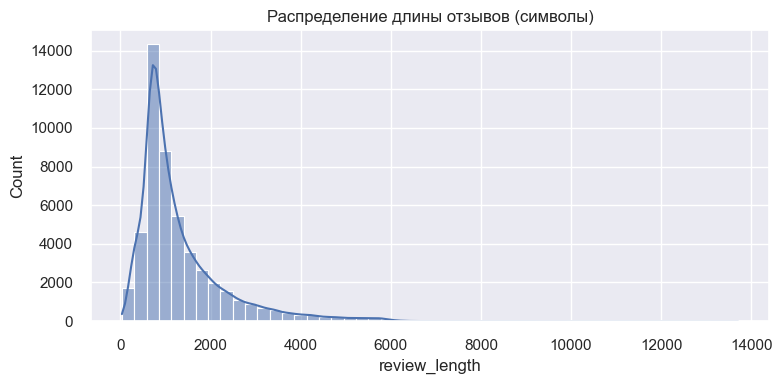

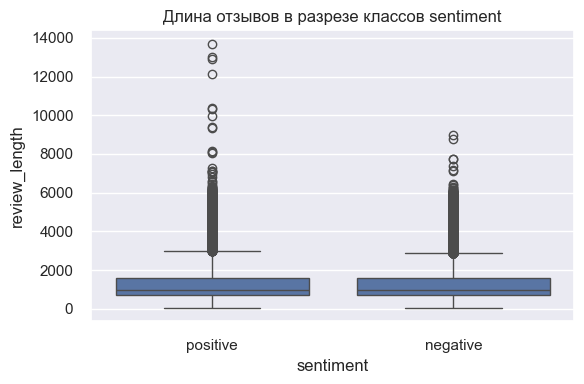

In [1]:
import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use("seaborn-v0_8")
sns.set_theme()

DATA_PATH = os.path.join("..", "datasets", "imdb", "IMDB Dataset.csv")

pd.set_option("display.max_colwidth", 200)

df = pd.read_csv(DATA_PATH)

print("Форма датасета:", df.shape)
display(df.head())

print("\nТипы столбцов:")
print(df.dtypes)

print("\nИнформация о данных:")
df.info()

print("\nЧисло дубликатов:", df.duplicated().sum())

missing = df.isna().sum().sort_values(ascending=False)
print("\nПропуски по столбцам:")
display(missing[missing > 0])

target_col = "sentiment"

if target_col in df.columns:
    print("\nРаспределение целевой переменной (sentiment):")
    display(df[target_col].value_counts(normalize=True))

df["review_length"] = df["review"].astype(str).str.len()

plt.figure(figsize=(8, 4))
sns.histplot(df["review_length"], bins=50, kde=True)
plt.title("Распределение длины отзывов (символы)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(x=target_col, y="review_length", data=df)
plt.title("Длина отзывов в разрезе классов sentiment")
plt.tight_layout()
plt.show()
